# Głębokie Uczenie w Praktyce
## Laboratorium 8
### Mateusz Horczak

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import sys
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
from numpy.exceptions import VisibleDeprecationWarning
warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)
warnings.filterwarnings("ignore")

In [9]:
def load_and_prepare_data(url, filename, maxlen=60, step=3):
    path = tf.keras.utils.get_file(filename, origin=url)
    text = open(path, encoding='utf-8').read().lower()
    print('Liczba znaków:', len(text))

    sentences = []
    next_chars = []
    for i in range(0, len(text) - maxlen, step):
        sentences.append(text[i: i + maxlen])
        next_chars.append(text[i + maxlen])
    print('Liczba wyodrębnionych sekwencji:', len(sentences))

    chars = sorted(list(set(text)))
    print('Liczba unikatowych znaków:', len(chars))
    char_indices = dict((char, chars.index(char)) for char in chars)

    x = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool_)
    y = np.zeros((len(sentences), len(chars)), dtype=np.bool_)

    for i, sentence in enumerate(sentences):
        for t, char in enumerate(sentence):
            x[i, t, char_indices[char]] = 1
        y[i, char_indices[next_chars[i]]] = 1

    return text, x, y, chars, char_indices

def build_and_train_model(x, y, chars, maxlen=60, epochs_num=5, title="Model"):
    model = Sequential()
    model.add(LSTM(128, input_shape=(maxlen, len(chars))))
    model.add(Dense(len(chars), activation='softmax'))

    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.01)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer)

    history = model.fit(x, y, batch_size=128, epochs=epochs_num)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs_num + 1), history.history['loss'], 'bo', label='Strata trenowania')
    plt.title(f'Spadek błędu podczas treningu ({title})', fontsize=14)
    plt.xlabel('Epoka', fontsize=12)
    plt.ylabel('Strata (Categorical Crossentropy)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return model

def sample(preds, temperature=1.0):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-7) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

def generate_text_from_model(model, text, chars, char_indices, maxlen=60, gen_length=200):
    start_index = random.randint(0, len(text) - maxlen - 1)
    generated_text_initial = text[start_index: start_index + maxlen]

    print('\n--- Generowanie przy użyciu tekstu początkowego: \n"' + generated_text_initial + '"\n')

    for temperature in [0.2, 0.5, 1.0, 1.2]:
        print(f'\n---> Wartość parametru temperature: {temperature}')
        sys.stdout.write(generated_text_initial)

        generated_text = generated_text_initial

        for i in range(gen_length):
            sampled = np.zeros((1, maxlen, len(chars)))
            for t, char in enumerate(generated_text):
                sampled[0, t, char_indices[char]] = 1

            preds = model.predict(sampled, verbose=0)[0]
            next_index = sample(preds, temperature)
            next_char = chars[next_index]

            generated_text += next_char
            generated_text = generated_text[1:]

            sys.stdout.write(next_char)
            sys.stdout.flush()
        print()

#### Ćwiczenie 1. Przygotowanie danych uczących

In [10]:
maxlen_val = 60

text_nietzsche, x_nietzsche, y_nietzsche, chars_nietzsche, char_indices_nietzsche = load_and_prepare_data(
    url='https://s3.amazonaws.com/text-datasets/nietzsche.txt',
    filename='nietzsche.txt',
    maxlen=maxlen_val
)

Liczba znaków: 600893
Liczba wyodrębnionych sekwencji: 200278
Liczba unikatowych znaków: 57


#### Ćwiczenie 2. Budowa sieci (Warstwy LSTM i Dense)
- LSTM służy do wyłapywania kolejności liter,
- Dense z softmax zwraca prawdopodobieństwo wystąpienia litery

Epoch 1/3
1565/1565 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - loss: 2.0208
Epoch 2/3
1565/1565 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - loss: 1.6430
Epoch 3/3
1565/1565 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - loss: 1.5361


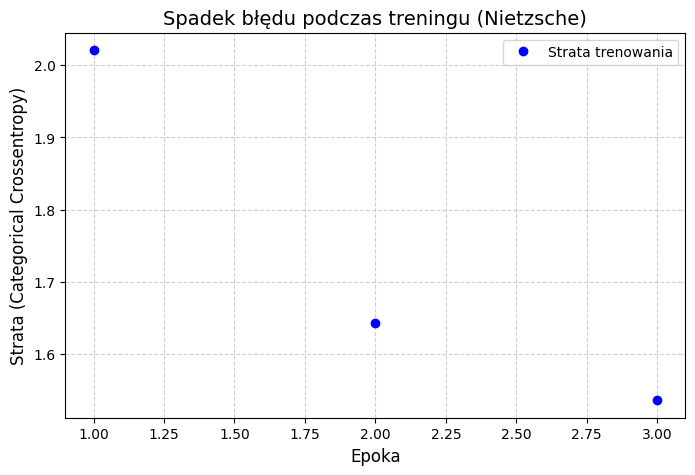

In [11]:
model_nietzsche = build_and_train_model(
    x_nietzsche, y_nietzsche, chars_nietzsche,
    maxlen=maxlen_val, epochs_num=3, title="Nietzsche"
)

#### Ćwiczenie 3. Generowanie tekstu
- Po wytrenowaniu modelu losujemy wycinek początkowy z tekstu (tzw. "ziarno").
- Następnie model znak po znaku dopisuje resztę tekstu. Sprawdzamy działanie dla różnej "temperatury"

In [12]:
generate_text_from_model(
    model_nietzsche, text_nietzsche, chars_nietzsche, char_indices_nietzsche,
    maxlen=maxlen_val, gen_length=200
)


--- Generowanie przy użyciu tekstu początkowego: 
"t is noble? what does the word "noble" still mean for us
now"


---> Wartość parametru temperature: 0.2
t is noble? what does the word "noble" still mean for us
now does and all the present strong and the surreture and the present still and soul the present the property and the present still of the strange and stranger and all the present strong and contempt of 

---> Wartość parametru temperature: 0.5
t is noble? what does the word "noble" still mean for us
now be morality, and grown the
world which this oppreath that who can there is a should where sufficient of expecially of being the strength the are that this allother feels there are for the christean i

---> Wartość parametru temperature: 1.0
t is noble? what does the word "noble" still mean for us
now houds for a degree of god or atles that it werebhat distomental heaven-arror", has ot.            sented, with learned from the privition best
mellest are
imperian inviences is pu

#### Ćwiczenie 4. Eksperymenty (Pan Tadeusz)

Liczba znaków: 447334
Liczba wyodrębnionych sekwencji: 149092
Liczba unikatowych znaków: 65
Epoch 1/3
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 2.3766
Epoch 2/3
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - loss: 2.0213
Epoch 3/3
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - loss: 1.8930


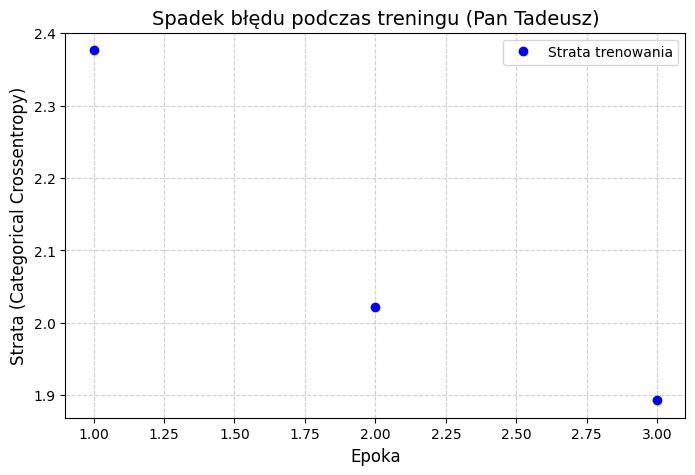


--- Generowanie przy użyciu tekstu początkowego: 
"zić
historyję o dziku nalibockich lasów
i o kłótni rejtana z"


---> Wartość parametru temperature: 0.2
zić
historyję o dziku nalibockich lasów
i o kłótni rejtana za szlachta powiecie powiecie,
i tak za szlachta pod koniec starczy się z konieci
choć starczy przecież się za wielkie strzelał,
za które szlachta powiedził się zaszczekł w kolewie,
i powietrzy się za 

---> Wartość parametru temperature: 0.5
zić
historyję o dziku nalibockich lasów
i o kłótni rejtana za trawą strunie,
obiedź i wielkie wojski wesokni koła skłonił
i ten wie, nie nie mogle z ile pownita rzekły.

    tyskąch powietrzył się tak nie tym przebierzy.
pojeniał za starotych komora pod niebo 

---> Wartość parametru temperature: 1.0
zić
historyję o dziku nalibockich lasów
i o kłótni rejtana znewu: fraźckisty,
nieżwobego — więcając zaksitcze je porojął kszwartlim,
postary na downę cięzą stedził złowi. wesy,
o panie, zaczął ciebić oplucisz, zuch
przepamienie chortkówły n

In [13]:
# 1. Przygotowanie danych (Mickiewicz)
text_pt, x_pt, y_pt, chars_pt, char_indices_pt = load_and_prepare_data(
    url='https://wolnelektury.pl/media/book/txt/pan-tadeusz.txt',
    filename='pan-tadeusz.txt',
    maxlen=maxlen_val
)

# 2. Trening modelu dla Pana Tadeusza
model_pt = build_and_train_model(
    x_pt, y_pt, chars_pt,
    maxlen=maxlen_val, epochs_num=3, title="Pan Tadeusz"
)

# 3. Generowanie tekstu w stylu Mickiewicza
generate_text_from_model(
    model_pt, text_pt, chars_pt, char_indices_pt,
    maxlen=maxlen_val, gen_length=200
)